# Урок 14. Итоговый проект: модель оттока клиентов

**Интерактивная версия:** `lessons/lesson_14/web/index.html`

Полное эталонное решение: данные → разбиение по времени → базовые модели → улучшения по одному →
объяснение → калибровка → проверка сдвига → сохранение модели.

In [1]:
import json
import sys
import tempfile
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))
sys.path.insert(0, str(ROOT / "lessons" / "lesson_14" / "examples"))

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score
from churn_data import FEATURES, make_churn, time_split
from gbcourse.plotting import use_course_style

use_course_style()

## 1. Данные и разбиение по времени

In [2]:
df = make_churn()
tr, va, te = time_split(df)
print(f"строк {len(df)}, клиентов {df.client.nunique()}, доля уходов {df.churn.mean():.3f}")
summary = pd.DataFrame({name: {"строк": len(p), "доля уходов": p.churn.mean(), "средний платёж": p.monthly_charge.mean(),
                               "пропусков usage_gb": p.usage_gb.isna().mean()} for name, p in (("обучение", tr), ("валидация", va), ("тест", te))})
summary.round(3)

строк 32719, клиентов 4000, доля уходов 0.060


,обучение,валидация,тест
строк,13041.000,7132.000,12546.000
доля уходов,0.065,0.048,0.061
средний платёж,48.720,46.894,52.658
пропусков usage_gb,0.095,0.096,0.092


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


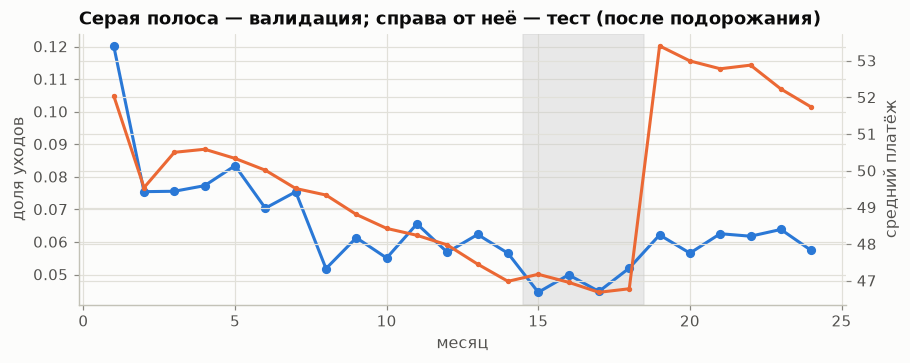

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.2))
monthly = df.groupby("month").agg(rate=("churn", "mean"), charge=("monthly_charge", "mean"))
ax.plot(monthly.index, monthly.rate, marker="o", label="доля уходов")
ax2 = ax.twinx()
ax2.plot(monthly.index, monthly.charge, color="#eb6834", marker=".", label="средний платёж")
ax.axvspan(14.5, 18.5, color="#ccc", alpha=0.4)
ax.set(xlabel="месяц", ylabel="доля уходов", title="Серая полоса — валидация; справа от неё — тест (после подорожания)")
ax2.set_ylabel("средний платёж")
plt.show()

## 2. Шаги решения

In [4]:
Xtr, Xva, Xte = tr[FEATURES], va[FEATURES], te[FEATURES]
ytr, yva, yte = tr.churn.to_numpy(), va.churn.to_numpy(), te.churn.to_numpy()
log = []


def record(step, p_va, p_te):
    row = {"шаг": step}
    for part, y, p in (("вал.", yva, p_va), ("тест", yte, p_te)):
        p = np.clip(p, 1e-6, 1 - 1e-6)
        row.update({f"log-loss {part}": log_loss(y, p), f"AUC {part}": roc_auc_score(y, p), f"AP {part}": average_precision_score(y, p)})
    log.append(row)


record("0. константа", np.full(len(yva), ytr.mean()), np.full(len(yte), ytr.mean()))
codes = lambda X: X.assign(**{c: X[c].cat.codes for c in ("contract", "payment", "region")})
m1 = lgb.LGBMClassifier(verbose=-1, random_state=0).fit(codes(Xtr), ytr)
record("1. LightGBM, коды категорий", m1.predict_proba(codes(Xva))[:, 1], m1.predict_proba(codes(Xte))[:, 1])
m2 = lgb.LGBMClassifier(verbose=-1, random_state=0).fit(Xtr, ytr)
record("2. встроенные категории", m2.predict_proba(Xva)[:, 1], m2.predict_proba(Xte)[:, 1])
m3 = lgb.LGBMClassifier(n_estimators=3000, learning_rate=0.05, verbose=-1, random_state=0)
m3.fit(Xtr, ytr, eval_X=(Xva,), eval_y=(yva,), callbacks=[lgb.early_stopping(100, verbose=False)])
record("3. ν = 0.05 + ранняя остановка", m3.predict_proba(Xva)[:, 1], m3.predict_proba(Xte)[:, 1])

rng = np.random.default_rng(0)
best = None
for _ in range(25):
    params = dict(num_leaves=int(rng.choice([4, 8, 16, 31, 64])), min_child_samples=int(rng.choice([10, 20, 50, 100, 200])),
                  colsample_bytree=float(rng.choice([0.5, 0.7, 1.0])), reg_lambda=float(rng.choice([0.0, 1.0, 10.0])),
                  cat_smooth=float(rng.choice([1.0, 10.0, 50.0])))
    m = lgb.LGBMClassifier(n_estimators=3000, learning_rate=0.05, verbose=-1, random_state=0, **params)
    m.fit(Xtr, ytr, eval_X=(Xva,), eval_y=(yva,), callbacks=[lgb.early_stopping(100, verbose=False)])
    score = min(m.evals_result_["valid_0"]["binary_logloss"])
    if best is None or score < best[0]:
        best = (score, params, m)
_, best_params, m4 = best
print("лучшие параметры:", best_params, "| деревьев:", m4.best_iteration_)
record("4. случайный поиск", m4.predict_proba(Xva)[:, 1], m4.predict_proba(Xte)[:, 1])
F_va, F_te = m4.predict(Xva, raw_score=True), m4.predict(Xte, raw_score=True)
platt = LogisticRegression(C=1e6).fit(F_va[:, None], yva)
record("5. калибровка Платта", platt.predict_proba(F_va[:, None])[:, 1], platt.predict_proba(F_te[:, None])[:, 1])
print(f"Платт: a = {platt.coef_[0, 0]:.3f}, b = {platt.intercept_[0]:.3f} — почти тождественное преобразование")
pd.DataFrame(log).round(4)

лучшие параметры: {'num_leaves': 8, 'min_child_samples': 200, 'colsample_bytree': 0.5, 'reg_lambda': 0.0, 'cat_smooth': 50.0} | деревьев: 123
Платт: a = 1.056, b = 0.061 — почти тождественное преобразование


,шаг,log-loss вал.,AUC вал.,AP вал.,log-loss тест,AUC тест,AP тест
0,0. константа,0.1950,0.5000,0.0480,0.2291,0.5000,0.0607
1,"1. LightGBM, коды категорий",0.1489,0.8469,0.3321,0.1789,0.8366,0.3618
2,2. встроенные категории,0.1508,0.8480,0.3247,0.1807,0.8373,0.3793
3,3. ν = 0.05 + ранняя остановка,0.1459,0.8526,0.3291,0.1721,0.8419,0.3926
4,4. случайный поиск,0.1422,0.8602,0.3602,0.1666,0.8564,0.4192
5,5. калибровка Платта,0.1420,0.8602,0.3602,0.1665,0.8564,0.4192


## 3. Объяснение: SHAP

`predict(..., pred_contrib=True)` в LightGBM возвращает точные значения TreeSHAP (последний столбец — база φ₀).

In [5]:
contrib = m4.predict(Xte, pred_contrib=True)
print("аддитивность: наибольшая |φ₀ + Σφ − F(x)| =", np.abs(contrib.sum(1) - F_te).max())
imp = pd.Series(np.abs(contrib[:, :-1]).mean(0), index=FEATURES).sort_values(ascending=False)
imp.round(4)

аддитивность: наибольшая |φ₀ + Σφ − F(x)| = 7.105427357601002e-15


monthly_charge      0.6281
contract            0.5828
region              0.2795
usage_gb            0.2706
tenure              0.2173
support_calls       0.2013
days_since_login    0.1486
payment             0.0570
age                 0.0464
dtype: float64

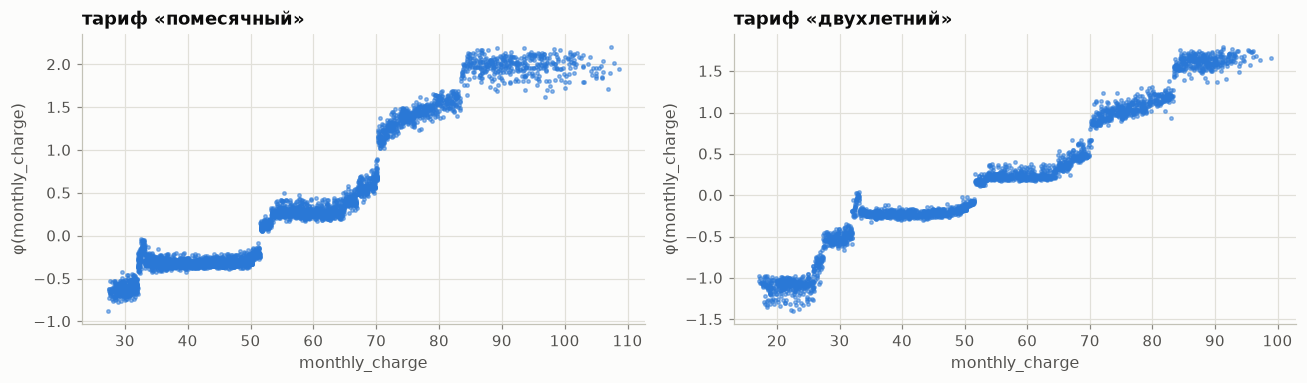

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
j = FEATURES.index("monthly_charge")
for ax, contract in zip(axes, ["помесячный", "двухлетний"]):
    mask = (Xte.contract == contract).to_numpy()
    ax.scatter(Xte.monthly_charge[mask], contrib[mask, j], s=5, alpha=0.5)
    ax.set(xlabel="monthly_charge", ylabel="φ(monthly_charge)", title=f"тариф «{contract}»")
plt.tight_layout()
plt.show()

Вклад платежа скачком растёт после 70 у обоих тарифов (средний φ: помесячный 0.51 → 1.24, двухлетний 0.44 → 0.96
при переходе от 65–70 к 70–75), у помесячного — сильнее. В данные заложено взаимодействие «помесячный × платёж > 70»,
но значения Шепли делят эффект взаимодействия между участниками (урок 12.2): часть его досталась признаку «тариф».

## 4. Сдвиг между обучением и тестом

In [7]:
def psi(a, b, bins=10):
    edges = np.quantile(a, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    pa = np.clip(np.histogram(a, edges)[0] / len(a), 1e-4, None)
    pb = np.clip(np.histogram(b, edges)[0] / len(b), 1e-4, None)
    return float(np.sum((pb - pa) * np.log(pb / pa)))


def adversarial_auc(feats):
    Z = pd.concat([Xtr[feats], Xte[feats]])
    lab = np.r_[np.zeros(len(Xtr)), np.ones(len(Xte))]
    perm = np.random.default_rng(1).permutation(len(Z))
    cut = int(0.7 * len(Z))
    clf = lgb.LGBMClassifier(n_estimators=200, verbose=-1).fit(Z.iloc[perm[:cut]], lab[perm[:cut]])
    return roc_auc_score(lab[perm[cut:]], clf.predict_proba(Z.iloc[perm[cut:]])[:, 1])


print(f"PSI monthly_charge: {psi(tr.monthly_charge.to_numpy(), te.monthly_charge.to_numpy()):.3f}")
print(f"PSI прогноза модели: {psi(m4.predict(Xtr, raw_score=True), F_te):.3f}")
pd.Series({"все признаки": adversarial_auc(FEATURES), "без платежа": adversarial_auc([f for f in FEATURES if f != "monthly_charge"]),
           "только платёж": adversarial_auc(["monthly_charge"]), "без возраста, региона, стажа": adversarial_auc(
               [f for f in FEATURES if f not in ("age", "region", "tenure")])}, name="AUC обучение/тест").round(3)

PSI monthly_charge: 0.049
PSI прогноза модели: 0.002


все признаки                    0.893
без платежа                     0.839
только платёж                   0.557
без возраста, региона, стажа    0.638
Name: AUC обучение/тест, dtype: float64

Высокий AUC со всеми признаками объясняется не только подорожанием: одни и те же клиенты есть в обеих частях,
и сочетание «возраст + регион + стаж» выдаёт клиента и период. Уберите эти признаки — и AUC упадёт.

## 5. Сохранение модели

In [8]:
with tempfile.TemporaryDirectory() as tmp:
    path = Path(tmp) / "churn_model.txt"
    m4.booster_.save_model(str(path))
    meta = {"lightgbm": lgb.__version__, "features": FEATURES, "params": best_params, "trees": int(m4.best_iteration_),
            "platt": [float(platt.coef_[0, 0]), float(platt.intercept_[0])], "valid_logloss": float(log[-1]["log-loss вал."])}
    (Path(tmp) / "churn_model.json").write_text(json.dumps(meta, ensure_ascii=False, indent=1), encoding="utf-8")
    loaded = lgb.Booster(model_file=str(path))
    print("прогнозы совпадают после загрузки:", np.allclose(loaded.predict(Xte, raw_score=True), F_te))
    print("метаданные:", json.dumps(meta, ensure_ascii=False)[:200], "…")

прогнозы совпадают после загрузки: True
метаданные: {"lightgbm": "4.7.0", "features": ["contract", "payment", "region", "age", "tenure", "monthly_charge", "support_calls", "usage_gb", "days_since_login"], "params": {"num_leaves": 8, "min_child_samples" …


## Упражнения

Смотрите `exercises/tasks.md`: новые признаки, CatBoost, обработка редких регионов, план мониторинга.